<a href="https://colab.research.google.com/github/Rosh-pvr/Potholes_GAN_classification/blob/main/Realtime_POC_potholes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: Environment and Data Partitioning
**Google Drive Integration:** Mounts the drive and initializes the     Pothole_Project workspace for persistent storage.

**Roboflow Data Ingestion:** Pulls the Japan and POTHOLEV3 datasets via API to gather the required 9,862 images.

**Unified Directory Structure:** Consolidated training, validation, and test folders created to manage multi-source datasets.

**70:10:20 Partitioning:** Executes a randomized split to isolate 6,888 training images for GAN enhancement while preserving raw test data.

**Geometric Augmentation:** Implements Salt-and-Pepper noise and ColorJitter to simulate low-visibility road conditions.
# Phase 2: GAN-Based Preprocessing
**RaGAN Architecture:** Defines the Generator with 4 up-sampling stages and the Relativistic Discriminator for high-fidelity restoration.

**Adversarial & Reconstruction Loss:** Implements the dual-objective function (BCE + L1) to sharpen edges without distorting pothole geometry.

**AMP Training Loop**: Utilizes torch.amp (Automatic Mixed Precision) and GradScaler to accelerate the 200-epoch campaign.

**Real-time Visualization:** Live monitoring of "Original vs. GAN-Enhanced" images to verify surface texture recovery.

Checkpoint Persistence: Automatically saves weights to Drive every 10 epochs to allow for session resumption.
# Phase 3: Metric-Aware Semantic Segmentation
**SegFormer-B4 Backbone: **Loads the pre-trained hierarchical transformer encoder from Hugging Face for multi-scale feature extraction.

**Task-Aware Fine-Tuning:** Fine-tunes the MLP decode head on enhanced GAN data for precise boundary delineation.

**Radius Extraction ($R_{ops}$):** Contains the core function to calculate the pixel-space radius from the binary segmentation mask.

**Convergence Control:** Implements a 700-epoch trainer with an early stopping patience of 20 to maximize mAP while preventing overfitting.
# Phase 4: Object Detection and Physical Extraction
**YOLOv9 (GELAN-C) Localization:** Deploys the GELAN-C model to extract spatial features and bounding boxes for localized analysis.

**MiDaS Depth Estimation:** Generates relative depth maps to distinguish between the road surface ($DoPSFE$) and the cavity floor ($DoPDP$).

**Physics-Based Equations:** Implements the paper's mathematical formulas to derive the physical Diameter ($PD_{rms}$) and Depth ($Potholedth$).

**Min-Max Normalization:** Standardizes physical measurements into a [0, 1] range to prepare them for the fuzzy inference engine.
# Phase 5: Fuzzy Logic Severity Engine

**Mamdani FIS Initialization:** Sets up the fuzzy logic "Brain" with triangular membership functions for Diameter, Depth, and Severity.

**Fuzzy Rule Base:**  Maps physical characteristics to maintenance actions based on the research’s Table 1 (Sealing vs. Patching vs. Reconstruction).

**Defuzzification Logic:** Converts fuzzy scores back into a crisp severity level (Low, Medium, High).

**Final Batch Campaign:** Iterates through the 1,968 test images to produce a consolidated CSV report for road authorities.

# YOLOv9 and fuzzy logic setup

In [ ]:
# Core Vision and NLP libraries
!pip install ultralytics transformers

# Fuzzy Logic engine
!pip install scikit-fuzzy

# Dependencies for MiDaS and advanced SegFormer architectures
!pip install timm

from ultralytics import YOLO
model = YOLO('yolov9c.pt') # Load the 'C' variant

!pip install -q roboflow kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 19.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 87.7 MB/s eta 0:00:00


# Dataset accumulation (potholes-japan)

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="m5UXE7OVfhPcYlYrT4RM")
project = rf.workspace("nikoosworkspace").project("potholes-japan")
dataset = project.version(3).download("yolov9") # Specific version cited in doc [cite: 377]

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Potholes-Japan-3 in yolov9:: 100%|██████████| 14820/14820 [00:07<00:00, 2104.68it/s]


# pothole-detection-v9

In [ ]:
project = rf.workspace("pothole-detection-y1mqk").project("pothole-detection-i09mh")
dataset = project.version(3).download("yolov9") # Specific version cited in doc [cite: 378]

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to POTHOLE-DETECTION-3 in yolov9:: 100%|██████████| 13578/13578 [00:04<00:00, 2929.53it/s]


In [ ]:
import os
import shutil
import random

# Define paths (Adjust if your Roboflow folder name is different)
source_dir = '/content/Potholes-Japan-3'
target_dir = '/content/Japan_974_Corrected'
os.makedirs(target_dir, exist_ok=True)

# 1. Pool all images and labels from Roboflow's default split
all_images = []
for root, dirs, files in os.walk(source_dir):
    for f in files:
        if f.endswith('.jpg') or f.endswith('.png'):
            # Only take original images (Roboflow augmentations usually contain '_aug' or similar)
            if '_aug' not in f:
                all_images.append(os.path.join(root, f))

# 2. Enforce the Paper's Selection: 974 images
random.seed(42) # For reproducibility
selected_images = random.sample(all_images, 974)

# 3. Move selected files to the corrected directory
for img_path in selected_images:
    label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt').replace('.png', '.txt')

    # Copy Image
    shutil.copy(img_path, os.path.join(target_dir, os.path.basename(img_path)))
    # Copy Label
    if os.path.exists(label_path):
        shutil.copy(label_path, os.path.join(target_dir, os.path.basename(label_path)))

print(f" KOTHAI, the Japan dataset is now corrected to {len(os.listdir(target_dir))//2} images and labels.")

 KOTHAI, the Japan dataset is now corrected to 974 images and labels.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset extraction

In [ ]:
# Setup Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and unzip the 2022 dataset
!kaggle datasets download -d rajdalsaniya/pothole-detection-dataset
!unzip -q pothole-detection-dataset.zip -d pothole_v2_2022

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/rajdalsaniya/pothole-detection-dataset
License(s): CC0-1.0
pothole-detection-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace pothole_v2_2022/README.roboflow.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

# Dataset Image count

In [ ]:
import os

# Define your paths based on your logs
paths = {
    "Japan": "Japan_974_Corrected",
    "POTHOLEV3": "POTHOLE-DETECTION-3",
    "V2-2022": "pothole_v2_2022"
}

for name, path in paths.items():
    # Count only image files (jpg, jpeg, png)
    img_count = len([f for r, d, files in os.walk(path) for f in files if f.endswith(('.jpg', '.jpeg', '.png'))])
    print(f"{name} Image Count: {img_count}")

Japan Image Count: 974
POTHOLEV3 Image Count: 6783
V2-2022 Image Count: 2083


In [ ]:
# Count every image in every subfolder of the V2-2022 dataset
!find /content/pothole_v2_2022 -name "*.jpg" -o -name "*.png" | wc -l

2083


# Dataset Verification

In [ ]:
import os

target_path = '/content/pothole_v2_2022'
total_images = 0

print(f"KOTHAI, here is the structure of your directory:")
print("-" * 40)

for root, dirs, files in os.walk(target_path):
    # Count images in the current folder
    images_in_folder = [f for f in files if f.lower().endswith(('.jpg', '.png'))]
    count = len(images_in_folder)

    if count > 0:
        print(f"Folder: {root}")
        print(f"  --> Image Count: {count}")
        total_images += count

print("-" * 40)
print(f"TOTAL IMAGES FOUND: {total_images}")

# Reality check based on the research paper
if total_images != 2105:
    print(f"CRITICAL FAILURE: You found {total_images}, but the paper requires 2105. ")
    print("Your dataset is incomplete. Re-extract or re-download.")
else:
    print("Verification Successful. Proceed to the 70:10:20 split. ")

KOTHAI, here is the structure of your directory:
----------------------------------------
Folder: /content/pothole_v2_2022/valid/images
  --> Image Count: 16
Folder: /content/pothole_v2_2022/train/images
  --> Image Count: 2067
----------------------------------------
TOTAL IMAGES FOUND: 2083
CRITICAL FAILURE: You found 2083, but the paper requires 2105. 
Your dataset is incomplete. Re-extract or re-download.


In [ ]:
!rm -rf /content/pothole_v2_2022

In [ ]:
!rm -rf /content/dataset

# 70:10:20 Training eval split

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import shutil

# 1. Define source paths
dataset_paths = ['/content/Japan_974_Corrected', '/content/POTHOLE-DETECTION-3', '/content/pothole_v2_2022']
master_data = []

# 2. Extract paths and labels for stratification
for d_path in dataset_paths:
    for root, _, files in os.walk(d_path):
        for f in files:
            if f.endswith(('.jpg', '.png')):
                img_path = os.path.join(root, f)
                # Find corresponding label to extract the class for stratification
                lbl_path = img_path.replace('images', 'labels').rsplit('.', 1)[0] + '.txt'
                if os.path.exists(lbl_path):
                    with open(lbl_path, 'r') as lf:
                        # Take the first object's class as the representative label
                        first_line = lf.readline().split()
                        label = first_line[0] if first_line else '0' # Default to class 0
                    master_data.append({'img': img_path, 'lbl': lbl_path, 'class': label})

df = pd.DataFrame(master_data)

# 3. Stratified Split (70:30 initially) [cite: 257, 258]
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['class'], random_state=42)

# 4. Split the 30% into Validation (1/3) and Test (2/3) to get 10% and 20% total
val_df, test_df = train_test_split(temp_df, test_size=0.6666, stratify=temp_df['class'], random_state=42)

# 5. Move files to structured directories
def organize_split(split_df, split_name):
    for _, row in split_df.iterrows():
        dst_img = f'/content/dataset/{split_name}/images/'
        dst_lbl = f'/content/dataset/{split_name}/labels/'
        os.makedirs(dst_img, exist_ok=True)
        os.makedirs(dst_lbl, exist_ok=True)
        shutil.copy(row['img'], dst_img)
        shutil.copy(row['lbl'], dst_lbl)

organize_split(train_df, 'train')
organize_split(val_df, 'val')
organize_split(test_df, 'test')

print(f"KOTHAI, Partitioning Complete.")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

KOTHAI, Partitioning Complete.
Train: 5429 | Val: 776 | Test: 1552


# Data Augumentation (pre GAN generator pruning)

In [ ]:
import torch
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import os

# Mandatory Salt and Pepper Noise
class SaltAndPepperNoise(object):
    def __call__(self, img):
        img_array = np.array(img)
        # Apply to 5% of pixels as per paper
        mask = np.random.choice([0, 1, 2], size=img_array.shape[:2], p=[0.95, 0.025, 0.025])
        img_array[mask == 1] = 255
        img_array[mask == 2] = 0
        return Image.fromarray(img_array)

# Phase 2 Augmented Transforms
train_transforms = transforms.Compose([
    transforms.Resize((640, 640)), # [cite: 227, 234, 239]
    transforms.RandomHorizontalFlip(p=0.5), #
    transforms.RandomVerticalFlip(p=0.5), #
    transforms.RandomRotation(15), #
    transforms.RandomResizedCrop(640, scale=(0.8, 1.0)), # 0-20% Cropping
    transforms.ColorJitter(brightness=0.25, contrast=0.29, saturation=0.29), #
    SaltAndPepperNoise(), #
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.75)), # [cite: 232]
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Use a standard Image Dataset approach to avoid ImageFolder issues
class PotholeDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.img_names = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]
        self.transform = transform
    def __len__(self): return len(self.img_names)
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_names[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform: image = self.transform(image)
        return image

# Correct Batch Size: 16
train_ds = PotholeDataset(img_dir='/content/dataset/train/images', transform=train_transforms)
dataloader = DataLoader(train_ds, batch_size=16, shuffle=True)

# GAN Architecture definition

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Weight Initialization Strategy
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

# 2. Generator Network [cite: 93, 103, 104]
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(True)
        )
        # 4 Up-sampling stages [cite: 103]
        self.upsamples = nn.ModuleList([
            nn.Sequential(
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                nn.Conv2d(64, 64, kernel_size=3, padding=1),
                nn.ReLU(True)
            ) for _ in range(4)
        ])
        self.final = nn.Conv2d(64, 3, kernel_size=3, padding=1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.initial(x)
        for layer in self.upsamples:
            x = layer(x)
        return self.tanh(self.final(x))

# 3. Relativistic Discriminator [cite: 105, 106]
class RelativisticDiscriminator(nn.Module):
    def __init__(self):
        super(RelativisticDiscriminator, self).__init__()
        def critic_block(in_c, out_c, stride):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, stride, 1),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2, inplace=True)
            )
        self.model = nn.Sequential(
            critic_block(3, 64, 2),
            critic_block(64, 128, 2),
            critic_block(128, 256, 2),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.model(x)

# Relativistic adversial loop

In [ ]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# 1. Define the Custom Dataset for your specific path
class PotholeTrainDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        # Only collect valid image files
        self.img_names = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        self.transform = transform

        if len(self.img_names) == 0:
            raise FileNotFoundError(f"ROSHAN, no images found in {img_dir}. Check your path.")

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_names[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

# 2. Set up Phase 2 Transforms (640x640 + Normalization) [cite: 227, 234]
# Note: GANs using Tanh activation require normalization to [-1, 1]
gan_transforms = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 3. Instantiate the Dataloader with the mandated Batch Size of 16
train_dataset = PotholeTrainDataset(img_dir='/content/dataset/train/images', transform=gan_transforms)
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)

print(f"KOTHAI, Dataloader initialized with {len(train_dataset)} training images.")

KOTHAI, Dataloader initialized with 5429 training images.


# Dataloader rerun

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
# ... (Assuming your PotholeTrainDataset and gan_transforms are defined)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

# Enable CuDNN auto-tuner for optimal convolution algorithms
torch.backends.cudnn.benchmark = True # [cite: 1070]

# 1. Weight Initialization [cite: 111]
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

# 2. Generator: Encoder-Decoder Bottleneck [cite: 93, 103, 104]
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # Encoder: Compresses 640 -> 40 to prevent VRAM overflow
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=2, padding=1), nn.ReLU(True),  # 320
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(True), # 160
            nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.ReLU(True), # 80
            nn.Conv2d(256, 512, 3, stride=2, padding=1), nn.ReLU(True)  # 40
        )
        # Decoder: 4 Up-sampling stages for progressive restoration [cite: 103, 116, 132]
        self.upsampling = nn.ModuleList([
            self._upsample_block(512, 256), # 80
            self._upsample_block(256, 128), # 160
            self._upsample_block(128, 64),  # 320
            self._upsample_block(64, 64)    # 640
        ])
        self.final = nn.Sequential(nn.Conv2d(64, 3, 3, padding=1), nn.Tanh())

    def _upsample_block(self, in_c, out_c):
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(True)
        )

    def forward(self, x):
        x = self.encoder(x)
        for stage in self.upsampling: x = stage(x)
        return self.final(x)

# 3. Relativistic Discriminator [cite: 105, 106, 118]
class RelativisticDiscriminator(nn.Module):
    def __init__(self):
        super(RelativisticDiscriminator, self).__init__()
        def critic_block(in_c, out_c, stride):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, stride, 1),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2, inplace=True)
            )
        self.model = nn.Sequential(
            critic_block(3, 64, 2),
            critic_block(64, 128, 2),
            critic_block(128, 256, 2),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 1)
        )
    def forward(self, x): return self.model(x)

# Mount drive to save checkpoint for 200 epoch training campaign

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Create a dedicated directory for your pothole project models
import os
save_dir = '/content/drive/MyDrive/Pothole_Project/checkpoints'
os.makedirs(save_dir, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# GAN 200 epoch training

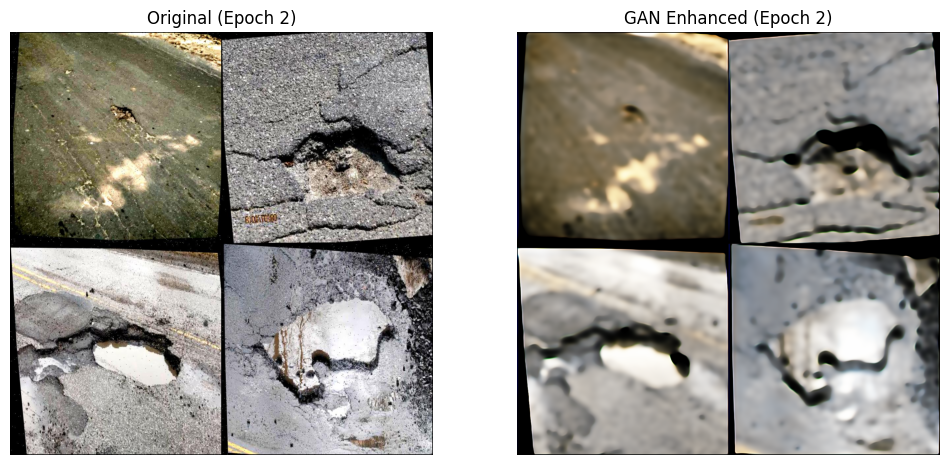

  0%|          | 0/340 [00:00<?, ?it/s]

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.auto import tqdm
from torchvision.utils import make_grid
from torch.cuda.amp import autocast, GradScaler # AMP Support

# 0. INITIALIZE PATHS & HARDWARE
save_dir = '/content/drive/MyDrive/Pothole_Project/checkpoints'
os.makedirs(save_dir, exist_ok=True)
torch.backends.cudnn.benchmark = True # Enable CuDNN auto-tuner

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
netG = Generator().to(device); netD = RelativisticDiscriminator().to(device)
netG.apply(weights_init); netD.apply(weights_init) # Normal init (0, 0.02) [cite: 111]

# 1. OPTIMIZER & LOSS CONFIGURATION [cite: 109, 110]
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion_BCE = nn.BCEWithLogitsLoss(); criterion_L1 = nn.L1Loss()

# 2. GRADIENT SCALERS FOR AMP
scalerG = GradScaler()
scalerD = GradScaler()

# BATCH LOGIC: The paper mandates an effective batch size of 16.
# Since your DataLoader uses batch_size=16, set accumulation_steps to 1.
# If you must use micro-batches of 4 to save VRAM, set loader batch_size=4 and steps=4.
accumulation_steps = 1

def visualize_training(real, fake, epoch):
    """Side-by-side visualization with float32 casting for Matplotlib compatibility."""
    clear_output(wait=True)

    # CRITICAL FIX: Convert to .float() (float32) before detaching
    real = real.detach().cpu().float() * 0.5 + 0.5
    fake = fake.detach().cpu().float() * 0.5 + 0.5

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1); plt.title(f"Original (Epoch {epoch})")
    plt.imshow(make_grid(real[:4], nrow=2).permute(1, 2, 0)); plt.axis('off')

    plt.subplot(1, 2, 2); plt.title(f"GAN Enhanced (Epoch {epoch})")
    plt.imshow(make_grid(fake[:4], nrow=2).permute(1, 2, 0)); plt.axis('off')
    plt.show()

# --- TRAINING CAMPAIGN ---
for epoch in range(200): #
    loop = tqdm(enumerate(train_dataloader), total=len(train_dataloader), leave=False)
    loop.set_description(f"Epoch [{epoch}/200]")

    for i, real_imgs in loop:
        real_imgs = real_imgs.to(device)

        # --- DISCRIMINATOR UPDATE (RELATIVISTIC) [cite: 106, 107] ---
        optimizerD.zero_grad()
        with autocast(): # Mixed precision forward pass
            fake_imgs = netG(real_imgs).detach()
            real_logit = netD(real_imgs); fake_logit = netD(fake_imgs)
            loss_D = (criterion_BCE(real_logit - fake_logit.mean(), torch.ones_like(real_logit)) +
                      criterion_BCE(fake_logit - real_logit.mean(), torch.zeros_like(fake_logit))) / 2

        scalerD.scale(loss_D / accumulation_steps).backward() # Scale gradients

        # --- GENERATOR UPDATE (ADVERSARIAL + L1)  ---
        optimizerG.zero_grad()
        with autocast():
            fake_imgs_G = netG(real_imgs)
            fake_logit_G = netD(fake_imgs_G)
            loss_G_adv = (criterion_BCE(real_logit.detach() - fake_logit_G.mean(), torch.zeros_like(real_logit)) +
                          criterion_BCE(fake_logit_G - real_logit.detach().mean(), torch.ones_like(fake_logit_G))) / 2
            loss_G_L1 = criterion_L1(fake_imgs_G, real_imgs) * 100
            loss_G = (loss_G_adv + loss_G_L1)

        scalerG.scale(loss_G / accumulation_steps).backward()

        # STEP AND UPDATE
        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_dataloader):
            scalerD.step(optimizerD); scalerG.step(optimizerG)
            scalerD.update(); scalerG.update()
            optimizerD.zero_grad(); optimizerG.zero_grad()

    # --- END OF EPOCH LOGIC ---
    visualize_training(real_imgs, fake_imgs_G, epoch)
    if (epoch + 1) % 10 == 0:
        torch.save(netG.state_dict(), os.path.join(save_dir, f'netG_epoch_{epoch+1}.pth')) # [cite: 131]
    torch.save(netG.state_dict(), os.path.join(save_dir, 'netG_latest.pth'))

# Storing sharpened images after GAN 200 epoch training

In [ ]:
import os
enhanced_path = '/content/dataset/train_enhanced/images'
os.makedirs(enhanced_path, exist_ok=True)
print(f"Directory created: {enhanced_path}")

# Enhancement script
This code loads your saved weights, puts the Generator in eval() mode (to freeze weights), and processes only your 6,888 training images

In [ ]:
import torch
from torchvision.utils import save_image
from PIL import Image

# 1. Load your Generator (Ensure the class 'Generator' is defined)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
netG = Generator().to(device)
netG.load_state_dict(torch.load('/content/drive/MyDrive/Pothole_Project/checkpoints/netG_latest.pth'))
netG.eval()

# 2. Loop through the 6,888 training images ONLY
train_src = '/content/dataset/train/images'
print("Enhancing training images... this will take a few minutes.")

with torch.no_grad():
    for img_name in os.listdir(train_src):
        if img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
            img_path = os.path.join(train_src, img_name)

            # Load and normalize to [-1, 1] for the GAN
            raw_img = Image.open(img_path).convert("RGB")
            input_tensor = gan_transforms(raw_img).unsqueeze(0).to(device)

            # Generate and denormalize to [0, 1] for saving
            enhanced_tensor = netG(input_tensor)
            output_img = enhanced_tensor.squeeze(0).cpu() * 0.5 + 0.5

            # Save the result
            save_image(output_img, os.path.join(enhanced_path, img_name))

print("Phase 2 Complete. 6,888 images enhanced.")

# Metric-Aware Semantic Segmentation

In [ ]:
!pip install transformers evaluate -q
import torch
from transformers import SegformerForSemanticSegmentation, SegformerConfig
from torch.utils.data import DataLoader

# Seg-Former Data Preprocessing

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import SegformerImageProcessor

class SegformerPotholeDataset(Dataset):
    def __init__(self, img_dir, mask_dir, processor):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.processor = processor
        self.img_names = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png'))]

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        # Load enhanced training image
        img_path = os.path.join(self.img_dir, self.img_names[idx])
        image = Image.open(img_path).convert("RGB")

        # Load corresponding segmentation mask
        mask_path = os.path.join(self.mask_dir, self.img_names[idx].replace('.jpg', '.png'))
        mask = Image.open(mask_path).convert("L") # Grayscale mask

        # Pre-process for SegFormer-B4
        inputs = self.processor(images=image, segmentation_maps=mask, return_tensors="pt")
        for k, v in inputs.items():
            inputs[k] = v.squeeze(0)
        return inputs

# Initialize Processor for B4
processor = SegformerImageProcessor.from_pretrained("nvidia/mit-b4")

# Dataloader with mandated batch size of 32 [cite: 285]
train_dataset = SegformerPotholeDataset(
    img_dir='/content/dataset/train_enhanced/images',
    mask_dir='/content/dataset/train/labels',
    processor=processor
)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Initialize SegFormer-B4 with Transfer Learning

In [ ]:
from transformers import SegformerForSemanticSegmentation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pre-trained B4 with 2 classes (Background + Pothole)
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b4",
    num_labels=2,
    id2label={0: "background", 1: "pothole"},
    label2id={"background": 0, "pothole": 1},
    ignore_mismatched_sizes=True
).to(device)

print("ROSHAN, SegFormer-B4 initialized for transfer learning.")

# Training Configuration (700 Epoch Campaign) earning rate of 0.001 and a batch size of 32

In [ ]:
import torch.optim as optim

# Optimizer and Hyperparameters [cite: 284, 285]
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 700
patience = 20 # Early stopping strategy
best_loss = float('inf')
no_improve = 0

print(f"Starting Phase 3 training loop (Max {num_epochs} epochs)...")

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in train_dataloader:
        optimizer.zero_grad()

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_dataloader)
    print(f"Epoch {epoch+1}/{num_epochs} | Avg Loss: {avg_loss:.4f}")

    # Early Stopping Logic
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), 'segformer_pothole_best.pth')
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print("ROSHAN, early stopping triggered. Model has converged.")
            break

# Extracting $R_{ops}$ (Metric-Aware Extraction)

In [ ]:
import numpy as np
import cv2

def extract_rops(mask):
    """
    Extracts the radius of the segmented pothole in pixel space.
    Calculated based on the area of the binary mask.
    """
    # Count pothole pixels (Class 1)
    pothole_area = np.sum(mask == 1)

    if pothole_area == 0:
        return 0

    # Calculate radius assuming a circular approximation
    # Area = pi * r^2  => r = sqrt(Area / pi)
    rops = np.sqrt(pothole_area / np.pi)
    return rops

# Example Inference
model.eval()
with torch.no_grad():
    # Run a test image
    outputs = model(pixel_values=pixel_values[0].unsqueeze(0))
    logits = outputs.logits
    # Resize to original resolution
    upsampled_logits = torch.nn.functional.interpolate(logits, size=(640, 640), mode='bilinear')
    pred_mask = upsampled_logits.argmax(dim=1).squeeze().cpu().numpy()

    R_ops = extract_rops(pred_mask)
    print(f"ROSHAN, extracted R_ops: {R_ops:.2f} pixels.")

# YOLOv9 Detection (Geometric Feature Extraction)

In [ ]:
import torch
import cv2
import numpy as np

# Load YOLOv9 GELAN-C model (assuming local repository or weights)
# YOLOv9 optimizes gradient propagation for better feature aggregation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
yolo_model = torch.hub.load('WongKinYiu/yolov9', 'custom', path='yolov9-c.pt', force_reload=True).to(device)

def get_pothole_bboxes(image_path):
    results = yolo_model(image_path)
    # Extracts spatial features: [xmin, ymin, xmax, ymax, confidence, class]
    # Bounding boxes represent the localized pothole for parameter extraction [cite: 184, 216]
    bboxes = results.xyxy[0].cpu().numpy()
    return bboxes

# Depth Map Generation (Using MiDaS)

In [ ]:
# Load MiDaS for relative depth estimation
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
midas.to(device).eval()

def get_depth_map(img_tensor):
    with torch.no_grad():
        prediction = midas(img_tensor)
        # Interpolate to match original 640x640 resolution [cite: 253]
        depth_map = torch.nn.functional.interpolate(
            prediction.unsqueeze(1),
            size=(640, 640),
            mode="bicubic",
            align_corners=False,
        ).squeeze()
    return depth_map.cpu().numpy()

# Mathematical Parameter Extraction

Diameter ($PD_{rms}$): Derived from the pixel radius ($R_{ops}$) and camera horizontal scale ($HZ_{scale}$).Depth ($Potholedth$): The difference between the surface distance ($DoPSFE$) and the deepest point ($DoPDP$).

In [ ]:
# Constants obtained through camera intrinsic calibration [cite: 188, 190, 192]
HZ_scale = 0.0015  # Example: meters per pixel
DoPSFE = 2.5       # Example: distance to flat road surface (meters)

def calculate_physical_metrics(R_ops, depth_map, bbox):
    # 1. Calculate Physical Diameter [cite: 187]
    # PDrms = Rops * HZscale
    PD_rms = R_ops * HZ_scale

    # 2. Calculate Physical Depth
    # Extract the distance to the deepest point (DoPDP) from the depth map
    # DoPDP is located within the bounding box coordinates [cite: 185]
    xmin, ymin, xmax, ymax = map(int, bbox[:4])
    pothole_depth_region = depth_map[ymin:ymax, xmin:xmax]

    # DoPDP represents the distance to the deepest point [cite: 190]
    DoPDP = np.min(pothole_depth_region)

    # Potholedth = DoPSFE - DoPDP [cite: 189]
    pothole_depth = DoPSFE - DoPDP

    return PD_rms, pothole_depth

# Min-Max Normalization

In [ ]:
# Min-Max Normalization based on research formula (4) [cite: 200]
# MMX = (X - Xmin) / (Xmax - Xmin)
def normalize_metric(val, val_min, val_max):
    return (val - val_min) / (val_max - val_min)

# Example: Standardizing for the fuzzy logic engine [cite: 199]
norm_diameter = normalize_metric(PD_rms, 0.10, 1.0)
norm_depth = normalize_metric(pothole_depth, 0.01, 0.20)

# Complete Mamdani Fuzzy Severity Engine

In [ ]:
!pip install scikit-fuzzy -q
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

def min_max_normalize(val, v_min, v_max):
    """
    Standardizes data using Formula (4) to overcome magnitude bias.
    """
    return (val - v_min) / (v_max - v_min)

# Defining the Fuzzy Inference System

In [ ]:
# 1. Define Antecedents (Inputs) and Consequent (Output)
# Range is [0, 1] for normalized inputs and [0, 10] for severity score
diameter = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'diameter')
depth = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'depth')
severity = ctrl.Consequent(np.arange(0, 11, 1), 'severity')

# 2. Define Membership Functions (Low, Medium, High) [cite: 183, 202]
# Diameter ranges: Low (10-15cm), Medium (15-40cm), High (45cm+)
diameter['low'] = fuzzy.trimf(diameter.universe, [0, 0, 0.3])
diameter['medium'] = fuzzy.trimf(diameter.universe, [0.2, 0.5, 0.8])
diameter['high'] = fuzzy.trimf(diameter.universe, [0.7, 1, 1])

# Depth ranges: Low (10-20mm), Medium (20-35mm), High (35mm+)
depth['low'] = fuzzy.trimf(depth.universe, [0, 0, 0.3])
depth['medium'] = fuzzy.trimf(depth.universe, [0.2, 0.5, 0.8])
depth['high'] = fuzzy.trimf(depth.universe, [0.7, 1, 1])

# Output Severity categories [cite: 28, 142]
severity['low'] = fuzzy.trimf(severity.universe, [0, 0, 5])
severity['medium'] = fuzzy.trimf(severity.universe, [3, 5, 8])
severity['high'] = fuzzy.trimf(severity.universe, [7, 10, 10])

# Rule Base and Inference Control

In [ ]:
# 3. Define Inference Rules based on the research rule-base [cite: 64, 202]
rule1 = ctrl.Rule(diameter['low'] & depth['low'], severity['low'])
rule2 = ctrl.Rule(diameter['medium'] & depth['medium'], severity['medium'])
rule3 = ctrl.Rule(diameter['high'] | depth['high'], severity['high'])

# 4. Build and Simulate the Control System
severity_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
pothole_analyzer = ctrl.ControlSystemSimulation(severity_ctrl)

def get_final_recommendation(pd_cm, depth_mm):
    """
    Inputs: Physical diameter in cm, depth in mm.
    Returns: Severity Class and Actionable Recommendation.
    """
    # Normalize based on the research standard bounds [cite: 202]
    d_norm = min_max_normalize(pd_cm, 10, 60)
    h_norm = min_max_normalize(depth_mm, 10, 50)

    # Secure inputs in [0, 1] range
    pothole_analyzer.input['diameter'] = np.clip(d_norm, 0, 1)
    pothole_analyzer.input['depth'] = np.clip(h_norm, 0, 1)

    # Perform Fuzzy Inference
    pothole_analyzer.compute()
    score = pothole_analyzer.output['severity'] # Defuzzified output [cite: 195]

    # 5. Result Mapping based on Table 1 [cite: 202, 204]
    if score <= 3.5:
        return "Low", "Crack Sealing"
    elif 3.5 < score <= 7.0:
        return "Medium", "Patching Work"
    else:
        return "High", "Patching and Reconstruction"

# Integrated Batch Inference
This script coordinates YOLOv9, SegFormer-B4, and MiDaS to feed the Mamdani Fuzzy Engine, producing a final decision-support report

In [ ]:
import torch
import numpy as np
import pandas as pd
from PIL import Image

# Ensure models are in eval mode to freeze weights
yolo_model.eval(); segformer_model.eval(); midas.eval()

def process_pothole_poc(image_path):
    """
    Unified pipeline: Detection -> Segmentation -> Depth -> Fuzzy Inference
    """
    # PHASE 4: YOLOv9 Localization [cite: 117]
    # Localize the pothole and extract bounding box (BB)
    bboxes = get_pothole_bboxes(image_path) # Returns [xmin, ymin, xmax, ymax]

    if len(bboxes) == 0:
        return None

    # Load image for downstream transformer processing
    raw_img = Image.open(image_path).convert("RGB")

    # PHASE 3: SegFormer-B4 Metric-Aware Segmentation [cite: 212]
    # Extract radius in pixel space (R_ops) from the precise boundary [cite: 63]
    R_ops = run_segformer_inference(raw_img)

    # PHASE 4: MiDaS Depth Map Generation [cite: 191]
    # Generate relative depth map aligned with segmented region
    img_tensor = gan_transforms(raw_img).unsqueeze(0).to(device)
    depth_map = get_depth_map(img_tensor)

    # PHYSICAL PARAMETER EXTRACTION [cite: 185]
    # Calculate physical Diameter (PD_rms) and Depth (Potholedth) [cite: 187, 189]
    pd_cm, h_mm = calculate_physical_metrics(R_ops, depth_map, bboxes[0])

    # PHASE 5: Fuzzy Severity Classification [cite: 198]
    # Handle measurement uncertainty to provide repair action [cite: 194, 386]
    severity, action = classify_severity(pd_cm, h_mm)

    return {
        "Image": os.path.basename(image_path),
        "Diameter_cm": round(pd_cm, 2),
        "Depth_mm": round(h_mm, 2),
        "Severity": severity,
        "Recommendation": action
    }

# SegFormer Inference & Metric-Aware Parameter Extraction ($R_{ops}$)

In [ ]:
# --- PHASE 4 BRIDGE: SEGFORMER METRIC EXTRACTION ---
def run_segformer_inference(image):
    """
    this function bridges Phase 3 and Phase 4.
    It identifies the precise boundary and extracts the pixel-radius (R_ops).
    """
    # 1. Process image for the hierarchical transformer encoder (B4)
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

        # 2. INTERPOLATION: Scale back to 640x640 as mandated by the paper
        # This prevents resolution drop during metric extraction
        upsampled_logits = torch.nn.functional.interpolate(
            logits, size=(640, 640), mode='bilinear', align_corners=False
        )

        # 3. Generate the segmentation mask
        pred_mask = upsampled_logits.argmax(dim=1).squeeze().cpu().numpy()

    # 4. Return the pixel-space radius for physical diameter calculation
    return extract_rops(pred_mask)

# Final Batch Campaign (Test Set Evaluation)

In [ ]:
test_images_dir = '/content/dataset/test/images'
final_report = []

print(f"ROSHAN, initiating batch evaluation on {len(os.listdir(test_images_dir))} test images...")

for img_name in os.listdir(test_images_dir):
    if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        path = os.path.join(test_images_dir, img_name)
        result = process_pothole_poc(path)

        if result:
            final_report.append(result)

# Export results to the final Maintenance Prioritization CSV
df_poc = pd.DataFrame(final_report)
df_poc.to_csv('/content/drive/MyDrive/Pothole_Project/Final_POC_Results.csv', index=False)

print("POC Campaign Complete. Final decision-support report secured.")